In [5]:
import pandas as pd
h1_df_visuels_exploratoires = pd.read_csv("https://raw.githubusercontent.com/lunettenoire/Project/refs/heads/main/df_h1.csv")

# On ne garde que les colonnes qui nous interessent
h1_df_visuels_exploratoires = h1_df_visuels_exploratoires[[
    "country_name",
    "year",
    "life_ladder",
    "log_gdp_per_capita",
    "healthy_life_expectancy_at_birth"]]

h1_df_visuels_exploratoires.to_csv('h1_df_visuels_exploratoires.csv', index=False)

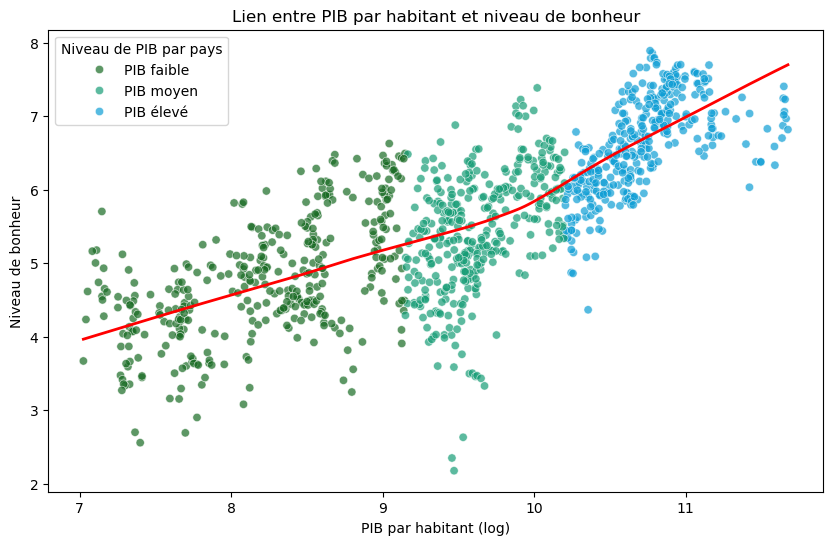

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

#Graphique n°1: PIB vs Bonheur

custom_palette = {"PIB faible": "#196B24", "PIB moyen": "#179D76", "PIB élevé": "#0F9ED5"}

h1_df_visuels_exploratoires["gdp_group"] = pd.qcut(h1_df_visuels_exploratoires["log_gdp_per_capita"], q=3, labels=["PIB faible", "PIB moyen", "PIB élevé"])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=h1_df_visuels_exploratoires,
    x="log_gdp_per_capita",
    y="life_ladder",
    hue="gdp_group",
    palette=custom_palette,
    alpha=0.7
)

# On appelle la légende pour modifier son titre
plt.legend(title="Niveau de PIB par pays")

sns.regplot(
    data=h1_df_visuels_exploratoires,
    x="log_gdp_per_capita",
    y="life_ladder",
    scatter=False,
    lowess=True,
    line_kws={"color": "red", "lw": 2}
)

plt.title("Lien entre PIB par habitant et niveau de bonheur")
plt.xlabel("PIB par habitant (log)")
plt.ylabel("Niveau de bonheur")

plt.savefig("h1_1_PIB_vs_bonheur.png", dpi=300, bbox_inches='tight')

plt.show()

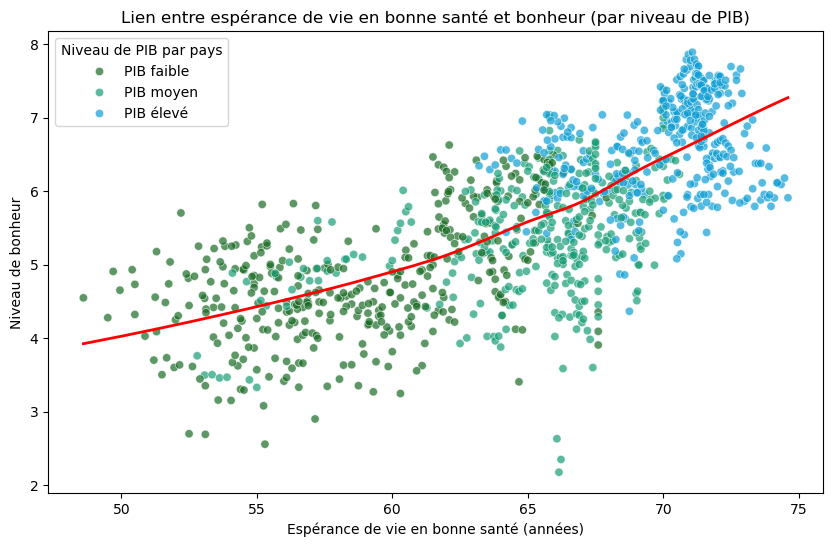

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Graphique n°2 : EVSI vs Bonheur (avec slicing par PIB)

# 1. On réutilise la palette du premier graphique (ou on l'adapte avec les bons noms)
custom_palette = {"PIB faible": "#196B24", "PIB moyen": "#179D76", "PIB élevé": "#0F9ED5"}

# 2. Création des groupes PIB (le "slicing")
h1_df_visuels_exploratoires["gdp_group"] = pd.qcut(
    h1_df_visuels_exploratoires["log_gdp_per_capita"], 
    q=3, 
    labels=["PIB faible", "PIB moyen", "PIB élevé"]
)

plt.figure(figsize=(10,6))

# 3. Scatterplot : x devient l'espérance de vie, mais le 'hue' reste le groupe de PIB
sns.scatterplot(
    data=h1_df_visuels_exploratoires, 
    x="healthy_life_expectancy_at_birth", 
    y="life_ladder", 
    hue="gdp_group", 
    palette=custom_palette, 
    alpha=0.7
)

# 4. On ajuste la légende pour expliquer que la couleur = PIB
plt.legend(title="Niveau de PIB par pays")

# 5. Régression (ligne rouge)
sns.regplot(
    data=h1_df_visuels_exploratoires, 
    x="healthy_life_expectancy_at_birth", 
    y="life_ladder", 
    scatter=False, 
    lowess=True, 
    line_kws={"color": "red", "lw": 2}
)

plt.title("Lien entre espérance de vie en bonne santé et bonheur (par niveau de PIB)")
plt.xlabel("Espérance de vie en bonne santé (années)")
plt.ylabel("Niveau de bonheur")

plt.savefig("h1_1_life_expectancy_vs_bonheur.png", dpi=300, bbox_inches='tight')
plt.show()